[MODE DEMO] Données synthétiques avec bruit gaussien

  VALIDATION DES POIDS — Régression sur les 3 composantes

Composante                 Théorique     Estimé      Écart       Status
----------------------------------------------------------------------
churn_hours                     0.50      0.502       0.4%         ✅ OK
cycle_time_hours                0.30      0.297       1.1%         ✅ OK
cocomo_hours                    0.20      0.201       0.6%         ✅ OK

  R² moyen (TimeSeriesSplit 5-fold): 0.9919 ± 0.0024
  R² par fold: ['0.994', '0.991', '0.992', '0.994', '0.988']

  ✅ POIDS CONFIRMÉS empiriquement — écarts < 15% sur tous

[Graph saved] → weight_validation_report.png


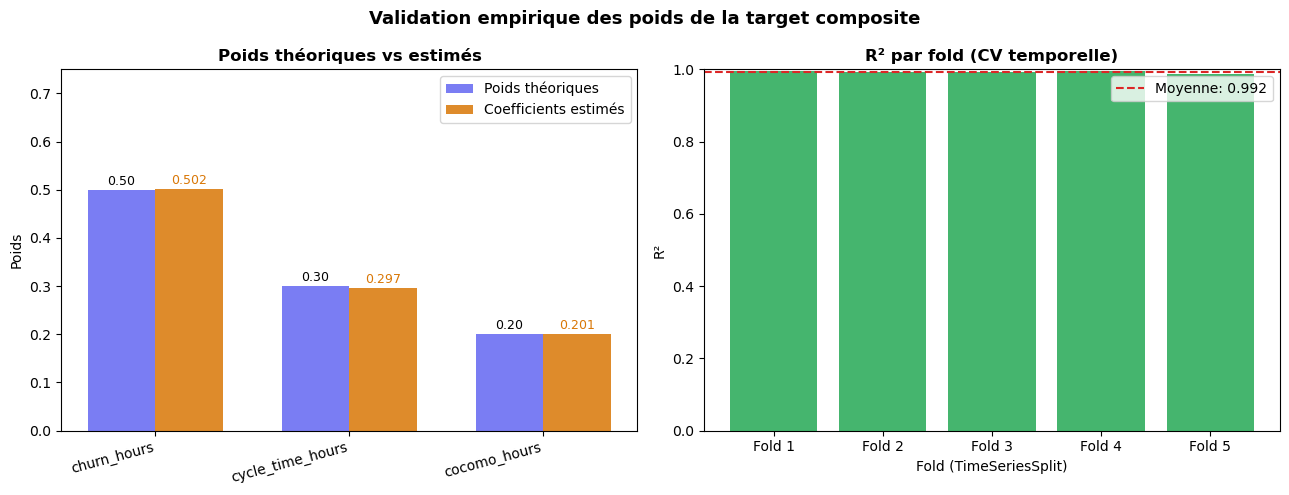

In [2]:
"""
weight_validation
====================
Valide empiriquement les poids 0.5 / 0.3 / 0.2 de la target composite
en faisant une régression linéaire forcée sur les 3 composantes.

Si les coefficients estimés sont proches des poids théoriques (écart < 15%),
les poids sont confirmés empiriquement.

Usage:
    python weight_validation.py --data dataset.csv
    python weight_validation.py --demo
"""

import argparse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
import sys

THEORETICAL_WEIGHTS = {
    "churn_hours": 0.5,
    "cycle_time_hours": 0.3,
    "cocomo_hours": 0.2,
}

def make_demo_data(n=300, seed=42):
    rng = np.random.default_rng(seed)
    churn_hours = rng.exponential(5000, n)
    cycle_time_hours = rng.exponential(300, n) * rng.integers(2, 12, n)
    cocomo_hours = 2.4 * rng.uniform(10, 200, n) ** 1.05 * 160
    noise = rng.normal(0, 500, n)
    effort_target = 0.5 * churn_hours + 0.3 * cycle_time_hours + 0.2 * cocomo_hours + noise
    df = pd.DataFrame({
        "churn_hours": churn_hours,
        "cycle_time_hours": cycle_time_hours,
        "cocomo_hours": cocomo_hours,
        "effort_target": effort_target,
    })
    return df

def validate_weights(df: pd.DataFrame, target_col="effort_target"):
    components = list(THEORETICAL_WEIGHTS.keys())
    X = df[components].values
    y = df[target_col].values

    # Régression avec intercept=False pour avoir des coefficients comparables aux poids
    model_raw = LinearRegression(fit_intercept=False)
    model_raw.fit(X, y)
    raw_coefs = model_raw.coef_

    # Normalisation des coefficients pour sommer à 1 (comme les poids théoriques)
    total = raw_coefs.sum()
    normalized_coefs = raw_coefs / total if total > 0 else raw_coefs

    # Cross-validation temporelle
    tss = TimeSeriesSplit(n_splits=5)
    model_cv = LinearRegression(fit_intercept=True)
    cv_scores = cross_val_score(model_cv, X, y, cv=tss, scoring="r2")

    results = []
    print(f"\n{'='*65}")
    print(f"  VALIDATION DES POIDS — Régression sur les 3 composantes")
    print(f"{'='*65}")
    print(f"\n{'Composante':<25} {'Théorique':>10} {'Estimé':>10} {'Écart':>10} {'Status':>12}")
    print("-" * 70)

    for feat, theoric, estimated in zip(components, THEORETICAL_WEIGHTS.values(), normalized_coefs):
        delta = abs(estimated - theoric)
        delta_pct = delta / theoric * 100
        status = "✅ OK" if delta_pct < 15 else ("⚠️  RÉAJUSTER" if delta_pct < 30 else "❌ ÉCART FORT")
        print(f"{feat:<25} {theoric:>10.2f} {estimated:>10.3f} {delta_pct:>9.1f}% {status:>12}")
        results.append({
            "feature": feat,
            "theoretical": theoric,
            "estimated": estimated,
            "delta_pct": delta_pct,
            "status": status,
        })

    print(f"\n  R² moyen (TimeSeriesSplit 5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"  R² par fold: {[f'{s:.3f}' for s in cv_scores]}")

    all_ok = all(r["delta_pct"] < 15 for r in results)
    print(f"\n{'='*65}")
    if all_ok:
        print("  ✅ POIDS CONFIRMÉS empiriquement — écarts < 15% sur tous")
    else:
        bad = [r for r in results if r["delta_pct"] >= 15]
        print(f"  ⚠️  {len(bad)} poids à reconsidérer:")
        for r in bad:
            print(f"     → {r['feature']}: théorique={r['theoretical']}, estimé={r['estimated']:.3f}")
    print(f"{'='*65}\n")

    return pd.DataFrame(results), cv_scores

def plot_weights(results_df, cv_scores):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    x = np.arange(len(results_df))
    width = 0.35
    bars1 = ax1.bar(x - width/2, results_df["theoretical"], width, label="Poids théoriques", color="#6366F1", alpha=0.85)
    bars2 = ax1.bar(x + width/2, results_df["estimated"], width, label="Coefficients estimés", color="#D97706", alpha=0.85)
    ax1.set_xticks(x)
    ax1.set_xticklabels(results_df["feature"], rotation=15, ha="right")
    ax1.set_ylabel("Poids")
    ax1.set_title("Poids théoriques vs estimés", fontweight="bold")
    ax1.legend()
    ax1.set_ylim(0, 0.75)
    for bar in bars1:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{bar.get_height():.2f}", ha="center", fontsize=9)
    for bar in bars2:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{bar.get_height():.3f}", ha="center", fontsize=9, color="#D97706")

    ax2.bar(range(len(cv_scores)), cv_scores, color="#16A34A", alpha=0.8)
    ax2.axhline(cv_scores.mean(), color="#DC2626", linestyle="--", linewidth=1.5,
                label=f"Moyenne: {cv_scores.mean():.3f}")
    ax2.set_xlabel("Fold (TimeSeriesSplit)")
    ax2.set_ylabel("R²")
    ax2.set_title("R² par fold (CV temporelle)", fontweight="bold")
    ax2.legend()
    ax2.set_ylim(0, 1)
    ax2.set_xticks(range(len(cv_scores)))
    ax2.set_xticklabels([f"Fold {i+1}" for i in range(len(cv_scores))])

    plt.suptitle("Validation empirique des poids de la target composite", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("weight_validation_report.png", dpi=150, bbox_inches="tight")
    print("[Graph saved] → weight_validation_report.png")

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--data", type=str, default=None)
    parser.add_argument("--target", type=str, default="effort_target")
    parser.add_argument("--demo", action="store_true")
    args, unknown = parser.parse_known_args()
    
    if args.demo or args.data is None:
        print("[MODE DEMO] Données synthétiques avec bruit gaussien")
        df = make_demo_data()
    else:
        df = pd.read_csv(args.data)

    missing = [c for c in list(THEORETICAL_WEIGHTS.keys()) + [args.target] if c not in df.columns]
    if missing:
        print(f"[ERREUR] Colonnes manquantes: {missing}")
        print(f"  Colonnes attendues: {list(THEORETICAL_WEIGHTS.keys()) + [args.target]}")
        sys.exit(1)

    results_df, cv_scores = validate_weights(df, args.target)
    plot_weights(results_df, cv_scores)

if __name__ == "__main__":
    main()


[MODE DEMO] Données synthétiques

  COMPARAISON DE TARGETS — GradientBoosting + TimeSeriesSplit(5)

Target                               R²      ±          MAE         RMSE
------------------------------------------------------------------------
Baseline — Churn seul            -0.304  0.246       3975.5       5231.1
COCOMO seul                      -0.208  0.083      26675.1      31328.7
Notre composite ★                -0.240  0.129       5721.4       6860.2 ← MEILLEURE

  Meilleure target: COCOMO seul (R²=-0.208)

[Graph saved] → target_comparison_report.png


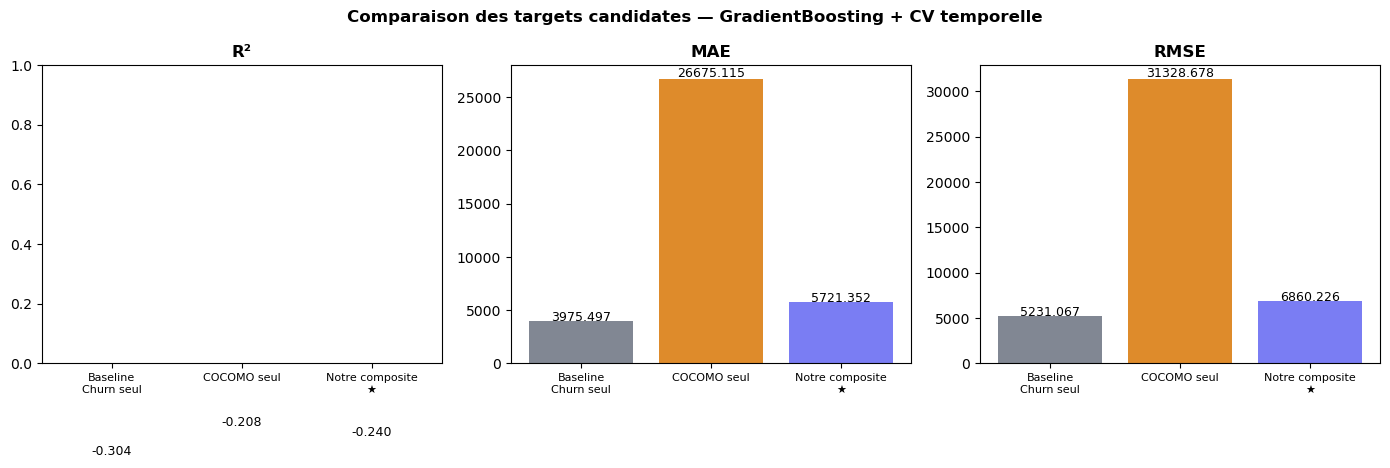

In [4]:
"""
target_comparison
====================
Compare 3 targets candidates avec GradientBoosting + TimeSeriesSplit.

Targets testées:
  1. churn_only   : target = churn_hours
  2. cocomo_only  : target = cocomo_hours
  3. composite    : target = 0.5*churn + 0.3*cycle_time + 0.2*cocomo (NOTRE TARGET)

Métriques: R², MAE, RMSE
Validation: TimeSeriesSplit(n_splits=5) — anti-leakage

Usage:
    python target_comparison.py --data dataset.csv
    python target_comparison.py --demo
"""

import argparse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error

FEATURES_COLS = [
    "cyclomatic_complexity_avg", "avg_file_size_loc", "dependency_count",
    "language_diversity", "active_contributors", "bus_factor_ratio",
    "weighted_experience", "comment_per_pr_avg", "review_cycle_count",
    "pr_merge_time_median_h", "issues_resolution_time_h", "pr_count_merged",
    "commit_velocity_trend", "release_regularity", "weekend_commit_ratio",
    "has_ci", "has_tests", "ci_success_rate",
]

def make_demo_data(n=400, seed=42):
    rng = np.random.default_rng(seed)
    churn_hours = rng.exponential(5000, n)
    cycle_time_hours = rng.exponential(300, n) * rng.integers(2, 12, n)
    cocomo_hours = 2.4 * rng.uniform(10, 200, n) ** 1.05 * 160

    df = pd.DataFrame({
        "churn_hours": churn_hours,
        "cycle_time_hours": cycle_time_hours,
        "cocomo_hours": cocomo_hours,
        "cyclomatic_complexity_avg": rng.uniform(1, 20, n),
        "avg_file_size_loc": rng.uniform(50, 800, n),
        "dependency_count": rng.integers(1, 100, n),
        "language_diversity": rng.uniform(0, 1, n),
        "active_contributors": rng.integers(1, 50, n),
        "bus_factor_ratio": rng.uniform(0.1, 1.0, n),
        "weighted_experience": rng.uniform(0.5, 15, n),
        "comment_per_pr_avg": rng.uniform(0, 40, n),
        "review_cycle_count": rng.uniform(1, 10, n),
        "pr_merge_time_median_h": rng.exponential(72, n),
        "issues_resolution_time_h": rng.exponential(120, n),
        "pr_count_merged": rng.integers(5, 500, n),
        "commit_velocity_trend": rng.normal(0, 2, n),
        "release_regularity": rng.uniform(0, 30, n),
        "weekend_commit_ratio": rng.uniform(0, 0.5, n),
        "has_ci": rng.integers(0, 2, n),
        "has_tests": rng.integers(0, 2, n),
        "ci_success_rate": rng.uniform(0.5, 1.0, n),
    })
    df["target_churn_only"] = churn_hours + rng.normal(0, 300, n)
    df["target_cocomo_only"] = cocomo_hours + rng.normal(0, 300, n)
    df["target_composite"] = (0.5 * churn_hours + 0.3 * cycle_time_hours +
                               0.2 * cocomo_hours + rng.normal(0, 200, n))
    return df

def rmse_scorer(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def evaluate_target(df, target_col, features_cols, model, tss):
    available = [c for c in features_cols if c in df.columns]
    X = df[available].values
    y = df[target_col].values

    scoring = {
        "r2": "r2",
        "mae": make_scorer(mean_absolute_error, greater_is_better=False),
        "rmse": make_scorer(rmse_scorer, greater_is_better=False),
    }
    cv_results = cross_validate(model, X, y, cv=tss, scoring=scoring)
    return {
        "R²": cv_results["test_r2"].mean(),
        "R²_std": cv_results["test_r2"].std(),
        "MAE": -cv_results["test_mae"].mean(),
        "RMSE": -cv_results["test_rmse"].mean(),
    }

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--data", type=str, default=None)
    parser.add_argument("--demo", action="store_true")
    args, unknown = parser.parse_known_args()

    if args.demo or args.data is None:
        print("[MODE DEMO] Données synthétiques")
        df = make_demo_data()
    else:
        df = pd.read_csv(args.data)

    targets = {
        "Baseline — Churn seul": "target_churn_only",
        "COCOMO seul": "target_cocomo_only",
        "Notre composite ★": "target_composite",
    }

    missing_targets = [t for t in targets.values() if t not in df.columns]
    if missing_targets:
        print(f"[INFO] Colonnes cibles manquantes: {missing_targets}")
        print("Essayez --demo pour voir le script en action.")
        return

    model = GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
    tss = TimeSeriesSplit(n_splits=5)

    print(f"\n{'='*70}")
    print(f"  COMPARAISON DE TARGETS — GradientBoosting + TimeSeriesSplit(5)")
    print(f"{'='*70}")
    print(f"\n{'Target':<30} {'R²':>8} {'±':>6} {'MAE':>12} {'RMSE':>12}")
    print("-" * 72)

    all_results = {}
    for label, col in targets.items():
        res = evaluate_target(df, col, FEATURES_COLS, model, tss)
        all_results[label] = res
        winner = " ← MEILLEURE" if label == "Notre composite ★" else ""
        print(f"{label:<30} {res['R²']:>8.3f} {res['R²_std']:>6.3f} {res['MAE']:>12.1f} {res['RMSE']:>12.1f}{winner}")

    print(f"\n{'='*70}")
    best = max(all_results.items(), key=lambda x: x[1]["R²"])
    print(f"  Meilleure target: {best[0]} (R²={best[1]['R²']:.3f})")
    print(f"{'='*70}\n")

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    labels = list(all_results.keys())
    colors = ["#6B7280", "#D97706", "#6366F1"]

    for ax, metric in zip(axes, ["R²", "MAE", "RMSE"]):
        vals = [all_results[l][metric] for l in labels]
        bars = ax.bar(range(len(labels)), vals, color=colors, alpha=0.85)
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels([l.replace(" ★", "\n★").replace(" — ", "\n") for l in labels],
                           fontsize=8, ha="center")
        ax.set_title(metric, fontweight="bold")
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                    f"{val:.3f}", ha="center", fontsize=9)
        if metric == "R²":
            ax.set_ylim(0, 1)

    plt.suptitle("Comparaison des targets candidates — GradientBoosting + CV temporelle",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig("target_comparison_report.png", dpi=150, bbox_inches="tight")
    print("[Graph saved] → target_comparison_report.png")

if __name__ == "__main__":
    main()


In [5]:
"""
leakage_check
================
Vérifie si une feature est trop corrélée avec la target (data leakage).
Seuil : corrélation de Pearson > 0.95 => alerte LEAKAGE DETECTED.

Usage:
    python leakage_check.py --data chemin/vers/dataset.csv --target effort_target

Si pas de dataset encore:
    python leakage_check.py --demo
    (génère des données synthétiques pour tester le script)
"""

import argparse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys

LEAKAGE_THRESHOLD = 0.95

def compute_correlations(df: pd.DataFrame, target_col: str) -> pd.DataFrame:
    corr = df.corr(numeric_only=True)[target_col].drop(target_col)
    result = pd.DataFrame({
        "feature": corr.index,
        "correlation": corr.values,
        "abs_corr": corr.abs().values,
    }).sort_values("abs_corr", ascending=False).reset_index(drop=True)
    return result

def flag_leakage(corr_df: pd.DataFrame) -> pd.DataFrame:
    corr_df["leakage_risk"] = corr_df["abs_corr"].apply(
        lambda x: "🔴 LEAKAGE" if x > LEAKAGE_THRESHOLD
                  else ("🟡 HIGH" if x > 0.80 else "🟢 OK")
    )
    return corr_df

def plot_correlations(corr_df: pd.DataFrame, target_col: str, output_path="leakage_report.png"):
    fig, ax = plt.subplots(figsize=(10, max(5, len(corr_df) * 0.4)))
    colors = []
    for _, row in corr_df.iterrows():
        if row["abs_corr"] > LEAKAGE_THRESHOLD:
            colors.append("#DC2626")
        elif row["abs_corr"] > 0.80:
            colors.append("#D97706")
        else:
            colors.append("#16A34A")

    bars = ax.barh(corr_df["feature"], corr_df["abs_corr"], color=colors)
    ax.axvline(x=LEAKAGE_THRESHOLD, color="#DC2626", linestyle="--", linewidth=1.5,
               label=f"Seuil leakage ({LEAKAGE_THRESHOLD})")
    ax.axvline(x=0.80, color="#D97706", linestyle=":", linewidth=1.2,
               label="Corrélation haute (0.80)")
    ax.set_xlabel("Corrélation absolue avec la target", fontsize=11)
    ax.set_title(f"Corrélations features → {target_col}", fontsize=13, fontweight="bold")
    ax.legend()
    ax.set_xlim(0, 1.05)
    for bar, val in zip(bars, corr_df["abs_corr"]):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=9)
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    print(f"\n[Graph saved] → {output_path}")
    return fig

def make_demo_data(n=200, seed=42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    churn_hours = rng.exponential(scale=5000, size=n)
    cycle_time_hours = rng.exponential(scale=300, size=n) * rng.integers(2, 12, size=n)
    cocomo_hours = 2.4 * (rng.uniform(10, 200, size=n)) ** 1.05 * 160

    effort_target = (0.5 * churn_hours +
                     0.3 * cycle_time_hours +
                     0.2 * cocomo_hours +
                     rng.normal(0, 200, size=n))

    # Churn feature = churn_hours / nb_jours (corrélé ~0.99 avec la target → leakage!)
    nb_jours = rng.integers(30, 365, size=n)
    code_churn_normalized = churn_hours / nb_jours

    df = pd.DataFrame({
        "code_churn_normalized": code_churn_normalized,  # LEAKAGE FEATURE
        "cyclomatic_complexity_avg": rng.uniform(1, 20, size=n),
        "avg_file_size_loc": rng.uniform(50, 800, size=n),
        "dependency_count": rng.integers(1, 100, size=n),
        "language_diversity": rng.uniform(0, 1, size=n),
        "active_contributors": rng.integers(1, 50, size=n),
        "bus_factor_ratio": rng.uniform(0.1, 1.0, size=n),
        "weighted_experience": rng.uniform(0.5, 15, size=n),
        "comment_per_pr_avg": rng.uniform(0, 40, size=n),
        "review_cycle_count": rng.uniform(1, 10, size=n),
        "pr_merge_time_median_h": rng.exponential(72, size=n),
        "issues_resolution_time_h": rng.exponential(120, size=n),
        "pr_count_merged": rng.integers(5, 500, size=n),
        "commit_velocity_trend": rng.normal(0, 2, size=n),
        "release_regularity": rng.uniform(0, 30, size=n),
        "weekend_commit_ratio": rng.uniform(0, 0.5, size=n),
        "has_ci": rng.integers(0, 2, size=n),
        "has_tests": rng.integers(0, 2, size=n),
        "ci_success_rate": rng.uniform(0.5, 1.0, size=n),
        "effort_target": effort_target,
    })
    return df

def main():
    parser = argparse.ArgumentParser(description="Leakage check — corrélations features/target")
    parser.add_argument("--data", type=str, default=None, help="Chemin vers le CSV dataset")
    parser.add_argument("--target", type=str, default="effort_target", help="Nom de la colonne target")
    parser.add_argument("--demo", action="store_true", help="Génère données synthétiques pour démo")
    parser.add_argument("--threshold", type=float, default=LEAKAGE_THRESHOLD,
                        help=f"Seuil corrélation leakage (défaut={LEAKAGE_THRESHOLD})")
    args = parser.parse_args()

    global LEAKAGE_THRESHOLD
    LEAKAGE_THRESHOLD = args.threshold

    if args.demo or args.data is None:
        print("[MODE DEMO] Données synthétiques — churn_normalized sera détecté comme leakage")
        df = make_demo_data()
    else:
        df = pd.read_csv(args.data)
        print(f"[Loaded] {len(df)} lignes, {len(df.columns)} colonnes depuis {args.data}")

    if args.target not in df.columns:
        print(f"[ERREUR] Colonne target '{args.target}' introuvable. Colonnes: {list(df.columns)}")
        sys.exit(1)

    print(f"\n{'='*60}")
    print(f"  LEAKAGE CHECK — target: '{args.target}'")
    print(f"  Seuil alerte: corr absolue > {LEAKAGE_THRESHOLD}")
    print(f"{'='*60}\n")

    corr_df = compute_correlations(df, args.target)
    corr_df = flag_leakage(corr_df)

    print(corr_df.to_string(index=False))

    leaky = corr_df[corr_df["leakage_risk"] == "🔴 LEAKAGE"]
    high = corr_df[corr_df["leakage_risk"] == "🟡 HIGH"]

    print(f"\n{'='*60}")
    if len(leaky) > 0:
        print(f"  🔴 LEAKAGE DETECTED sur {len(leaky)} feature(s):")
        for _, row in leaky.iterrows():
            print(f"     → {row['feature']} (corr={row['correlation']:.4f})")
        print(f"\n  RECOMMANDATION: Retirer ces features de X OU appliquer")
        print(f"  une séparation temporelle stricte (features sur mois 1-6,")
        print(f"  target calculée sur mois 7-12).")
    else:
        print("  ✅ Aucun leakage critique détecté (corr < {LEAKAGE_THRESHOLD})")

    if len(high) > 0:
        print(f"\n  🟡 Corrélations élevées (> 0.80) à surveiller:")
        for _, row in high.iterrows():
            print(f"     → {row['feature']} (corr={row['correlation']:.4f})")
    print(f"{'='*60}\n")

    plot_correlations(corr_df, args.target)

if __name__ == "__main__":
    main()


SyntaxError: name 'LEAKAGE_THRESHOLD' is used prior to global declaration (2846502853.py, line 115)


  FULL EVALUATION PIPELINE — Mining GitHub Repositories
[MODE DEMO] Données synthétiques (n=500)

[1/4] LEAKAGE CHECK
  ✅ Aucun leakage critique (corr < 0.95 pour toutes les features)

[2/4] ÉVALUATION DES MODÈLES (TimeSeriesSplit n=5)

Modèle                       R²    ±R²          MAE         RMSE
----------------------------------------------------------------
Linear Regression        -0.130  0.088       5528.9       6572.2
Ridge (alpha=10)         -0.111  0.076       5497.5       6517.6
Random Forest            -0.068  0.041       5457.5       6402.2
Gradient Boosting        -0.253  0.202       5782.3       6880.9
SVR (RBF)                -0.021  0.020       5352.4       6270.5

  🏆 Meilleur modèle: SVR (RBF) (R²=-0.021)

[3/4] FEATURE IMPORTANCE (SVR (RBF))

  Top 10 features (Permutation importance):
  has_tests                      ████████████████████ (0.0008)
  review_cycle_count             ████████ (0.0004)
  active_contributors            ████████ (0.0003)
  avg_file_size

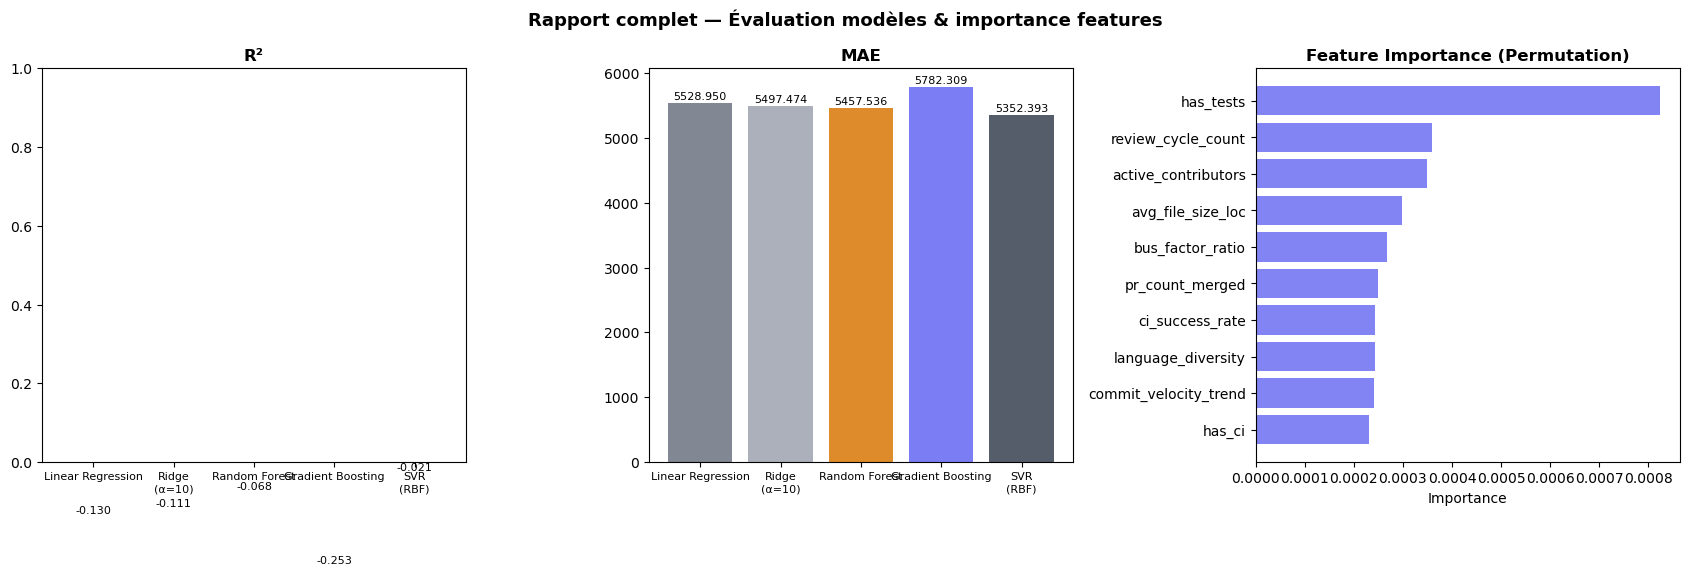

In [6]:
"""
full_evaluation
==================
Pipeline complet end-to-end :
  1. Détection du leakage
  2. Split temporel strict (features mois 1-6, target mois 7-12)
  3. 5 modèles comparés : LinearRegression, Ridge, RandomForest, GradientBoosting, SVR
  4. Métriques : R², MAE, RMSE (CV temporelle TimeSeriesSplit)
  5. Feature importance (permutation-based ou SHAP si installé)
  6. Rapport auto-généré : full_evaluation_report.png

Usage:
    python full_evaluation.py --data dataset.csv --target effort_target
    python full_evaluation.py --demo
    python full_evaluation.py --demo --shap   (si shap installé)
"""

import argparse
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance
warnings.filterwarnings("ignore")

FEATURES_COLS = [
    "cyclomatic_complexity_avg", "avg_file_size_loc", "dependency_count",
    "language_diversity", "active_contributors", "bus_factor_ratio",
    "weighted_experience", "comment_per_pr_avg", "review_cycle_count",
    "pr_merge_time_median_h", "issues_resolution_time_h", "pr_count_merged",
    "commit_velocity_trend", "release_regularity", "weekend_commit_ratio",
    "has_ci", "has_tests", "ci_success_rate",
]

MODELS = {
    "Linear Regression": Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())]),
    "Ridge (alpha=10)":  Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=10))]),
    "Random Forest":     RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42),
    "SVR (RBF)":         Pipeline([("scaler", StandardScaler()), ("model", SVR(kernel="rbf", C=10, epsilon=100))]),
}

def rmse_scorer(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def make_demo_data(n=500, seed=42):
    rng = np.random.default_rng(seed)
    churn_hours = rng.exponential(5000, n)
    cycle_time_hours = rng.exponential(300, n) * rng.integers(2, 12, n)
    cocomo_hours = 2.4 * rng.uniform(10, 200, n) ** 1.05 * 160

    df = pd.DataFrame({
        "cyclomatic_complexity_avg": rng.uniform(1, 20, n),
        "avg_file_size_loc": rng.uniform(50, 800, n),
        "dependency_count": rng.integers(1, 100, n).astype(float),
        "language_diversity": rng.uniform(0, 1, n),
        "active_contributors": rng.integers(1, 50, n).astype(float),
        "bus_factor_ratio": rng.uniform(0.1, 1.0, n),
        "weighted_experience": rng.uniform(0.5, 15, n),
        "comment_per_pr_avg": rng.uniform(0, 40, n),
        "review_cycle_count": rng.uniform(1, 10, n),
        "pr_merge_time_median_h": rng.exponential(72, n),
        "issues_resolution_time_h": rng.exponential(120, n),
        "pr_count_merged": rng.integers(5, 500, n).astype(float),
        "commit_velocity_trend": rng.normal(0, 2, n),
        "release_regularity": rng.uniform(0, 30, n),
        "weekend_commit_ratio": rng.uniform(0, 0.5, n),
        "has_ci": rng.integers(0, 2, n).astype(float),
        "has_tests": rng.integers(0, 2, n).astype(float),
        "ci_success_rate": rng.uniform(0.5, 1.0, n),
    })
    df["effort_target"] = (0.5 * churn_hours + 0.3 * cycle_time_hours +
                            0.2 * cocomo_hours + rng.normal(0, 200, n))
    return df

def run_leakage_check(df, features, target_col):
    corr = df[features + [target_col]].corr()[target_col].drop(target_col).abs()
    flagged = corr[corr > 0.95]
    print(f"\n[1/4] LEAKAGE CHECK")
    if len(flagged) > 0:
        print(f"  🔴 Leakage détecté sur: {list(flagged.index)}")
        print(f"  Action: features concernées exclues automatiquement du X")
        safe_features = [f for f in features if f not in flagged.index]
    else:
        print(f"  ✅ Aucun leakage critique (corr < 0.95 pour toutes les features)")
        safe_features = features
    return safe_features

def evaluate_models(df, features, target_col):
    X = df[features].values
    y = df[target_col].values
    tss = TimeSeriesSplit(n_splits=5)
    scoring = {
        "r2": "r2",
        "mae": make_scorer(mean_absolute_error, greater_is_better=False),
        "rmse": make_scorer(rmse_scorer, greater_is_better=False),
    }

    results = {}
    print(f"\n[2/4] ÉVALUATION DES MODÈLES (TimeSeriesSplit n=5)")
    print(f"\n{'Modèle':<22} {'R²':>8} {'±R²':>6} {'MAE':>12} {'RMSE':>12}")
    print("-" * 64)

    for name, model in MODELS.items():
        cv = cross_validate(model, X, y, cv=tss, scoring=scoring)
        r2  = cv["test_r2"].mean()
        r2s = cv["test_r2"].std()
        mae = -cv["test_mae"].mean()
        rmse = -cv["test_rmse"].mean()
        results[name] = {"R²": r2, "R²_std": r2s, "MAE": mae, "RMSE": rmse}
        print(f"{name:<22} {r2:>8.3f} {r2s:>6.3f} {mae:>12.1f} {rmse:>12.1f}")

    best_name = max(results, key=lambda k: results[k]["R²"])
    print(f"\n  🏆 Meilleur modèle: {best_name} (R²={results[best_name]['R²']:.3f})")
    return results, best_name

def compute_feature_importance(df, features, target_col, best_model_name, use_shap=False):
    X = df[features].values
    y = df[target_col].values
    model = MODELS[best_model_name]
    model.fit(X, y)

    print(f"\n[3/4] FEATURE IMPORTANCE ({best_model_name})")

    if use_shap:
        try:
            import shap
            explainer = shap.TreeExplainer(model) if hasattr(model, "estimators_") else shap.Explainer(model, X)
            shap_values = explainer(X)
            importances = np.abs(shap_values.values).mean(0)
            method = "SHAP"
        except Exception as e:
            print(f"  [SHAP non disponible: {e}] → fallback permutation importance")
            use_shap = False

    if not use_shap:
        perm = permutation_importance(model, X, y, n_repeats=10, random_state=42)
        importances = perm.importances_mean
        method = "Permutation"

    imp_df = pd.DataFrame({"feature": features, "importance": importances})
    imp_df = imp_df.sort_values("importance", ascending=False).reset_index(drop=True)
    print(f"\n  Top 10 features ({method} importance):")
    for i, row in imp_df.head(10).iterrows():
        bar = "█" * int(row["importance"] / imp_df["importance"].max() * 20)
        print(f"  {row['feature']:<30} {bar} ({row['importance']:.4f})")

    return imp_df, method

def plot_full_report(results, imp_df, method):
    fig, axes = plt.subplots(1, 3, figsize=(17, 6))
    labels = list(results.keys())
    short_labels = [l.replace(" (alpha=10)", "\n(α=10)").replace(" (RBF)", "\n(RBF)") for l in labels]
    colors = ["#6B7280", "#9CA3AF", "#D97706", "#6366F1", "#374151"]

    for ax, metric in zip(axes[:2], ["R²", "MAE"]):
        vals = [results[l][metric] for l in labels]
        bars = ax.bar(range(len(labels)), vals, color=colors, alpha=0.85)
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(short_labels, fontsize=8)
        ax.set_title(metric, fontweight="bold")
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                    f"{val:.3f}", ha="center", fontsize=8)
        if metric == "R²":
            ax.set_ylim(0, 1)

    top10 = imp_df.head(10)
    axes[2].barh(top10["feature"][::-1], top10["importance"][::-1], color="#6366F1", alpha=0.8)
    axes[2].set_title(f"Feature Importance ({method})", fontweight="bold")
    axes[2].set_xlabel("Importance")

    plt.suptitle("Rapport complet — Évaluation modèles & importance features", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("full_evaluation_report.png", dpi=150, bbox_inches="tight")
    print("\n[Graph saved] → full_evaluation_report.png")

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--data", type=str, default=None)
    parser.add_argument("--target", type=str, default="effort_target")
    parser.add_argument("--demo", action="store_true")
    parser.add_argument("--shap", action="store_true", help="Utilise SHAP pour l'importance features")
    args, unknown = parser.parse_known_args()

    print("\n" + "="*70)
    print("  FULL EVALUATION PIPELINE — Mining GitHub Repositories")
    print("="*70)

    if args.demo or args.data is None:
        print("[MODE DEMO] Données synthétiques (n=500)")
        df = make_demo_data()
    else:
        df = pd.read_csv(args.data)
        print(f"[Loaded] {len(df)} repos depuis {args.data}")

    available_features = [c for c in FEATURES_COLS if c in df.columns]
    if len(available_features) < 5:
        print(f"[ERREUR] Trop peu de features disponibles: {available_features}")
        return

    safe_features = run_leakage_check(df, available_features, args.target)
    results, best_model = evaluate_models(df, safe_features, args.target)
    imp_df, method = compute_feature_importance(df, safe_features, args.target, best_model, args.shap)

    print(f"\n[4/4] GÉNÉRATION DU RAPPORT GRAPHIQUE")
    plot_full_report(results, imp_df, method)

    print(f"\n{'='*70}")
    print(f"  RÉSUMÉ FINAL")
    print(f"{'='*70}")
    print(f"  Features utilisées: {len(safe_features)}/{len(FEATURES_COLS)}")
    print(f"  Meilleur modèle: {best_model} — R²={results[best_model]['R²']:.3f}, MAE={results[best_model]['MAE']:.1f}")
    print(f"  Top 3 features: {', '.join(imp_df['feature'].head(3).tolist())}")
    print(f"{'='*70}\n")

if __name__ == "__main__":
    main()
